In [55]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver


In [56]:
llm = ChatOllama(model="qwen2.5:3b")

In [57]:
class chatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [58]:
def chatBot(state):

    message = state['messages']

    response = llm.invoke(message)

    if not response.content and not response.tool_calls:
        response = AIMessage(
            content="I couldn't process your request. Please try again or rephrase your request."
        )

    return {'messages': [response]}


In [59]:
checkpointer= InMemorySaver()
graph = StateGraph(chatState)
graph.add_node('chatBot', chatBot)
graph.add_edge(START, 'chatBot')
graph.add_edge('chatBot', END)

chatBot = graph.compile(checkpointer=checkpointer)

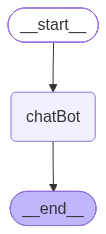

In [60]:
chatBot

In [61]:
thread_id='1'
while True:
    question = input("Enter your question (or type 'exit' to quit): ")
    if question.strip().lower() in  ['exit', 'quit', 'q']:
        break
    config={'configurable':{'thread_id':thread_id}}
    initial_state = {'messages': [HumanMessage(content=question)]}
    final_state = chatBot.invoke(initial_state, config=config)
    print(final_state['messages'][-1].content)

Hello! How can I assist you today?
Hello Tasrif! It looks like there might have been a typo in your greeting. How can I assist you today? Do you have a specific question or topic you'd like to discuss?
Your name is Tasrif. How can I assist you further with that information?
